# Gradient Descent

## Learning objective

This notebook introduces **gradient descent**, the workhorse optimization
method behind much of machine learning. Using a simple one-dimensional linear
regression problem you should come away able to:

- describe gradient descent as iteratively stepping downhill on a loss
  surface,
- write the mean squared error and its gradients by hand,
- run batch gradient descent to fit an intercept and a slope, and
- explain the role of the learning rate and why feature scaling matters.

## The mathematical idea

We model a target $y$ as a straight line in one feature $x$:

$$
\hat{y} = w_0 + w_1 x,
$$

where $w_0$ is the intercept and $w_1$ is the slope. For $n$ training points we
measure fit with the **mean squared error (MSE)**:

$$
J(w_0, w_1) = \frac{1}{n} \sum_{i=1}^{n}
\left( \hat{y}_i - y_i \right)^2 .
$$

Gradient descent improves the parameters by repeatedly stepping in the
direction that decreases $J$ the fastest, i.e. *against* the gradient. With
residual $r_i = \hat{y}_i - y_i$ the partial derivatives are

$$
\frac{\partial J}{\partial w_0} = \frac{2}{n} \sum_{i=1}^{n} r_i,
\qquad
\frac{\partial J}{\partial w_1} = \frac{2}{n} \sum_{i=1}^{n} r_i\, x_i,
$$

and each step updates the parameters as

$$
w \leftarrow w - \eta\, \nabla J(w),
$$

with learning rate $\eta > 0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## A synthetic 1D regression problem

We generate data from a known line, `y = 4 + 3x + noise`, so we can compare the
fitted parameters against the true ones.

In [2]:
true_intercept = 4.0
true_slope = 3.0

n_samples = 100
x = rng.uniform(-3, 3, size=n_samples)
noise = rng.normal(0, 1.5, size=n_samples)
y = true_intercept + true_slope * x + noise

print('x range:', round(x.min(), 2), 'to', round(x.max(), 2))
print('y range:', round(y.min(), 2), 'to', round(y.max(), 2))

x range: -2.98 to 2.98
y range: -7.65 to 14.97


## MSE and its gradient from scratch

We write two small functions: one for the loss and one for its gradient with
respect to the intercept and slope.

In [3]:
def predict(x, w0, w1):
    return w0 + w1 * x


def mse_loss(x, y, w0, w1):
    residual = predict(x, w0, w1) - y
    return np.mean(residual ** 2)


def mse_gradient(x, y, w0, w1):
    residual = predict(x, w0, w1) - y
    n = len(y)
    grad_w0 = (2.0 / n) * np.sum(residual)
    grad_w1 = (2.0 / n) * np.sum(residual * x)
    return grad_w0, grad_w1

## Running batch gradient descent

Starting from zero parameters, each iteration uses **all** training points
(hence *batch*) to compute the gradient, takes a step, and records the current
loss so we can watch it shrink.

In [4]:
learning_rate = 0.05
n_iterations = 200

w0, w1 = 0.0, 0.0
loss_history = []

for _ in range(n_iterations):
    loss_history.append(mse_loss(x, y, w0, w1))
    grad_w0, grad_w1 = mse_gradient(x, y, w0, w1)
    w0 -= learning_rate * grad_w0
    w1 -= learning_rate * grad_w1

final_loss = mse_loss(x, y, w0, w1)
loss_history.append(final_loss)

print('Learned intercept w0:', round(w0, 4))
print('Learned slope w1:', round(w1, 4))
print('True intercept / slope:', true_intercept, '/', true_slope)
print('Final MSE:', round(final_loss, 4))

Learned intercept w0: 3.8908
Learned slope w1: 2.9673
True intercept / slope: 4.0 / 3.0
Final MSE: 2.1151


## The loss history

Plotting the recorded loss shows the optimizer descending toward a minimum. A
healthy run drops quickly and then flattens out.

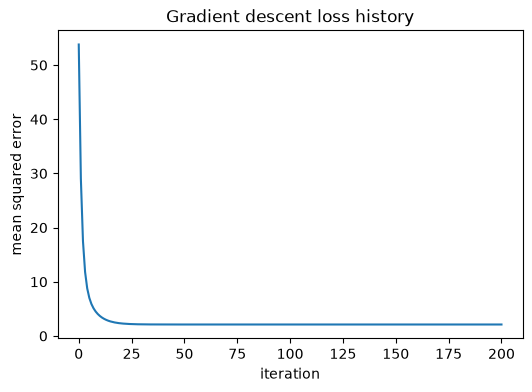

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history)
ax.set_xlabel('iteration')
ax.set_ylabel('mean squared error')
ax.set_title('Gradient descent loss history')
plt.show()

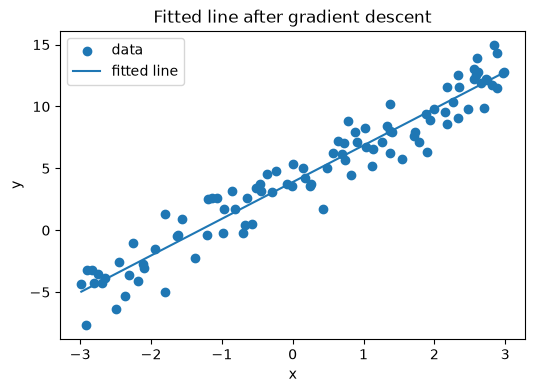

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, label='data')
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, predict(x_line, w0, w1), label='fitted line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Fitted line after gradient descent')
ax.legend()
plt.show()

## Interpretation

The learned intercept and slope land close to the true values used to generate
the data, and the fitted line passes through the middle of the cloud of points.
The loss curve falls steeply at first, when the gradients are large, and then
levels off as the parameters approach the minimum and the gradients shrink.

## Learning rate, convergence, and feature scaling

- **Learning rate $\eta$.** This controls the step size. Too small and the loss
  creeps down slowly, wasting iterations; too large and the steps overshoot the
  minimum, so the loss can stall or even diverge. A useful diagnostic is simply
  to plot the loss history, as we did above.
- **Convergence.** For a convex loss like MSE with a suitable learning rate,
  gradient descent is guaranteed to approach the global minimum. We stop after a
  fixed number of iterations here; in practice one often stops when the loss
  stops improving by more than a small tolerance.
- **Feature scaling.** When features live on very different scales, the loss
  surface becomes stretched and a single learning rate serves some directions
  poorly, slowing convergence and making the run sensitive to $\eta$. Standardizing
  features (zero mean, unit variance) makes the surface more symmetric and lets
  gradient descent converge faster and more reliably.

### Limitations and next steps

- Batch gradient descent uses the whole dataset each step, which is expensive
  for very large datasets; **stochastic** and **mini-batch** variants address
  this.
- The fixed learning rate and iteration count are chosen by hand; adaptive
  methods and learning-rate schedules can help.
- For ordinary least squares specifically there is a closed-form solution (the
  normal equation), which the next notebook explores.